In [1]:
import numpy as np
from PIL import Image
from IPython.display import display

In [2]:
from __future__ import annotations

NUM_ROWS = 28
NUM_COLS = 28
NUM_LABELS = 10

class Data:
  def __init__(self, pixels: list[list[int]], label: int):
    self.pixels = pixels
    self.flattened_pixels: list[int] = []
    for row in self.pixels:
      assert len(row) == NUM_ROWS
      self.flattened_pixels.extend(row)
    self.flattened_pixels = [pixel / 255.0 for pixel in self.flattened_pixels]
    
    self.label = label
  
  @classmethod
  def from_csv_row(cls, csv: list[int]) -> Data:
    label = csv[0]
    pixels: list[list[int]] = []
    for row in range(NUM_ROWS):
      start_index = 1 + row * NUM_ROWS
      pixels.append(csv[start_index : start_index + NUM_COLS])

    return cls(pixels, label)
  
  def to_image(self) -> Image:
    pixel_array = np.array(self.pixels, dtype=np.uint8)
    return Image.fromarray(pixel_array, mode='L')
  
  def label_to_one_hot(self) -> list[int]:
    result = [0] * NUM_LABELS
    result[self.label] = 1
    return result

In [3]:
lines: list[str] = []
datas: list[Data] = []

with open('data/MNIST_CSV/mnist_train.csv') as f:
  lines = f.readlines()

for line in lines:
  datas.append(Data.from_csv_row([int(num) for num in line.split(',')]))

In [4]:
print(datas[0].label)
print(datas[0].label_to_one_hot())
display(datas[0].to_image())

5
[0, 0, 0, 0, 0, 1, 0, 0, 0, 0]


In [5]:
distinct_labels = set()
for data in datas:
  distinct_labels.add(data.label)

In [6]:
distinct_labels

{0, 1, 2, 3, 4, 5, 6, 7, 8, 9}

## Train

In [7]:
from deep_learning.layer import get_layer
from deep_learning.multi_layer_perceptron import MultiLayerPerceptron
from deep_learning.op import TANH
from deep_learning.value import Value

from deep_learning.util import xavier_uniform
from deep_learning.util import zero_all_gradients
from deep_learning.util import softmax
from deep_learning.util import cross_entropy
from datetime import datetime

In [8]:
# build graph

input_values = [Value(0.0, label=f'pixel_{i}') for i in range(NUM_ROWS*NUM_COLS)]
output_values = [Value(0.0, label=f'label_{i}') for i in range(len(distinct_labels))]

multi_layer_perceptron = MultiLayerPerceptron(
    layers=[
        get_layer(
            num_weights_per_neuron=NUM_ROWS*NUM_COLS,
            num_neurons=32,
            activation=TANH,
            fn_weight_initializer=lambda: xavier_uniform(NUM_ROWS*NUM_COLS, 32),
        ),
        get_layer(
            num_weights_per_neuron=32,
            num_neurons=NUM_LABELS,
        ),
    ],
)
predicted_output = multi_layer_perceptron.build_graph(input_values)
softmax_output = softmax(predicted_output)
loss = cross_entropy(
    distribution=output_values,
    predicted_distribution=softmax_output,
)

In [9]:
# topologically sort graph
topologically_sorted_graph: list[Value] = []
visited: set[Value] = set()

def _traverse(
    node: Value,
    topologically_sorted_graph: list[Value],
    visited: set[Value],
) -> None:
  # NOTE: assume acyclic for simplicity
  if node in visited:
    return
  elif len(node.children) == 0:
    visited.add(node)
    topologically_sorted_graph.append(node)
  else:
    for child in node.children:
      _traverse(child, topologically_sorted_graph, visited)
    visited.add(node)
    topologically_sorted_graph.append(node)
_traverse(loss, topologically_sorted_graph, visited)

In [10]:
# `Value.forward()` recursively populates `node.data`. since `node.data` is already set for leaf nodes, we omit them
forward_order = [node for node in topologically_sorted_graph if len(node.children) > 0]

# `Value.backward()` recursively populates `node.gradient`. since leaf nodes get their gradients populated by their parents, we omit them
# this decomposes to just reversed `forward``_order`
backward_order = list(reversed(forward_order))

In [11]:
data_index = 0

In [12]:
losses: list[float] = []

In [13]:
for i in range(len(datas)):
  # compute loss
  data = datas[data_index]
  for input_value, pixel in zip(input_values, data.flattened_pixels, strict=True):
    input_value.data = float(pixel)
  for output_value, label_one_hot in zip(output_values, data.label_to_one_hot(), strict=True):
    output_value.data = label_one_hot
  
  # instead of `loss.forward()` we do
  for node in forward_order:
    node.data = node.op.forward([child.data for child in node.children])

  losses.append(loss.data)

  if i % 100 == 0 and i > 0:
    window = losses[-100:]
    print(f'{datetime.now().strftime("%H:%M:%S")} {i=} mean_t100_loss={sum(window)/len(window):.4f}')

  # backwards
  # instead of `zero_all_gradients(loss)` we do
  for node in topologically_sorted_graph:
    node.gradient = 0
  loss.gradient = 1.0
  
  # instead of `loss.backward()` we do
  for node in backward_order:
    children_local_derivatives = node.op.backward([child.data for child in node.children])
    zipped: list[tuple[Value, float]] = zip(node.children, children_local_derivatives, strict=True)
    for child, local_derivative in zipped:
      child.gradient += local_derivative * node.gradient

  # adjust parameters
  alpha = 0.01
  for layer in multi_layer_perceptron.layers:
    for neuron in layer.neurons:
      for weight_value in neuron.weight_values:
        weight_value.data = weight_value.data + (weight_value.gradient * -alpha)
      neuron.bias_value.data = neuron.bias_value.data + (neuron.bias_value.gradient * -alpha)

  # update state
  data_index = (data_index + 1) % len(datas)

06:40:07 i=100 mean_t100_loss=2.6591
06:40:14 i=200 mean_t100_loss=1.4121
06:40:20 i=300 mean_t100_loss=1.2227
06:40:26 i=400 mean_t100_loss=0.7759
06:40:32 i=500 mean_t100_loss=0.9540
06:40:38 i=600 mean_t100_loss=1.0251
06:40:43 i=700 mean_t100_loss=1.1030
06:40:49 i=800 mean_t100_loss=0.7598
06:40:54 i=900 mean_t100_loss=1.0375
06:41:00 i=1000 mean_t100_loss=0.8343
06:41:06 i=1100 mean_t100_loss=1.1221
06:41:12 i=1200 mean_t100_loss=0.8033
06:41:17 i=1300 mean_t100_loss=0.9939
06:41:23 i=1400 mean_t100_loss=0.8853
06:41:28 i=1500 mean_t100_loss=0.5003
06:41:34 i=1600 mean_t100_loss=0.7527
06:41:40 i=1700 mean_t100_loss=0.4666
06:41:45 i=1800 mean_t100_loss=0.3555
06:41:51 i=1900 mean_t100_loss=0.5677
06:41:57 i=2000 mean_t100_loss=0.5546
06:42:03 i=2100 mean_t100_loss=0.8044
06:42:08 i=2200 mean_t100_loss=0.3560
06:42:14 i=2300 mean_t100_loss=0.4712
06:42:19 i=2400 mean_t100_loss=0.4324
06:42:25 i=2500 mean_t100_loss=0.6711
06:42:31 i=2600 mean_t100_loss=0.2447
06:42:37 i=2700 mean_

In [14]:
import matplotlib.pyplot as plt

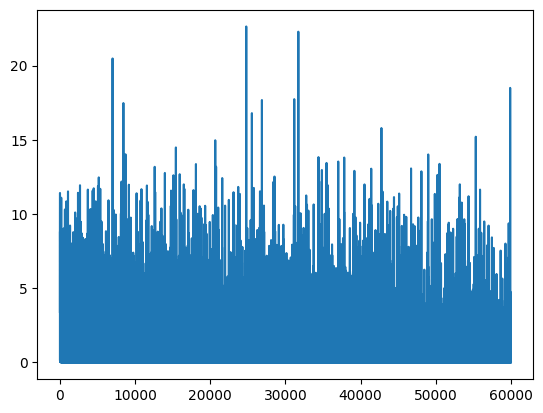

In [15]:
# noisy
plt.plot(losses)

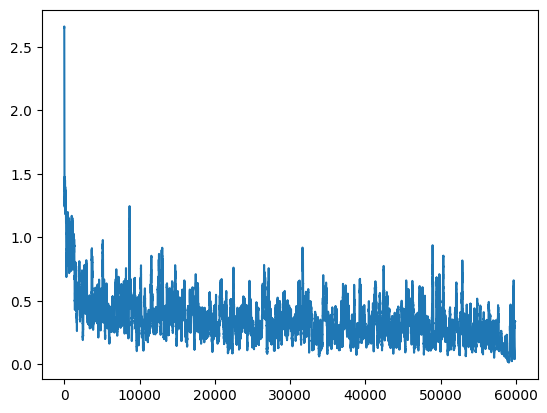

In [16]:
# smooth
mean_t100_losses: list[float] = []
for i in range(100, len(losses)):
  mean_t100_losses.append(sum(losses[i-100:i]) / 100)

plt.plot(mean_t100_losses)

## Pickle

In [17]:
import pickle

class Model:
  def __init__(
      self,
      input_values: list[Value],
      output_values: list[Value],
      multi_layer_perceptron_output: Value,
      softmax_output: list[Value],
      loss: Value,
  ):
    self.input_values = input_values
    self.output_values = output_values
    self.multi_layer_perceptron_output = multi_layer_perceptron_output
    self.softmax_output = softmax_output
    self.loss = loss

In [18]:
model = Model(
    input_values=input_values,
    output_values=output_values,
    multi_layer_perceptron_output=predicted_output,
    softmax_output=softmax_output,
    loss=loss,
)

# NOTE: commented out after running to prevent dumb accidental overwrite errors
with open('data/MNIST_CSV/model.pkl', 'wb') as file:
  pickle.dump(model, file)

In [19]:
model: Model = None
with open('data/MNIST_CSV/model.pkl', 'rb') as file:
  model = pickle.load(file)

## Predict

In [20]:
data = datas[0]
for input_value, pixel in zip(model.input_values, data.flattened_pixels, strict=True):
  input_value.data = float(pixel)
for output_value, label_one_hot in zip(model.output_values, data.label_to_one_hot(), strict=True):
  output_value.data = label_one_hot
model.loss.forward()

for i, p_label in enumerate(model.softmax_output):
  print(f'P({i}): {p_label.data:4f}')

prediction = max(range(len(model.softmax_output)), key=lambda i: model.softmax_output[i].data)
prediction

P(0): 0.000016
P(1): 0.000149
P(2): 0.000009
P(3): 0.007396
P(4): 0.000000
P(5): 0.992385
P(6): 0.000004
P(7): 0.000002
P(8): 0.000035
P(9): 0.000004


5

## Test

In [21]:
lines: list[str] = []
test_datas: list[Data] = []

with open('data/MNIST_CSV/mnist_test.csv') as f:
  lines = f.readlines()

for line in lines:
  test_datas.append(Data.from_csv_row([int(num) for num in line.split(',')]))

In [22]:
print(test_datas[0].label)
print(test_datas[0].label_to_one_hot())
display(test_datas[0].to_image())

7
[0, 0, 0, 0, 0, 0, 0, 1, 0, 0]


In [23]:
class TestOutcome:
  def __init__(
      self,
      test_case_index: int,
      correct_label: int,
      predicted_label: int,
      predicted_label_to_probability: dict[int, float],
  ):
    test_case_index = test_case_index
    self.correct_label = correct_label
    self.predicted_label = predicted_label
    self.predicted_label_to_probability = predicted_label_to_probability

  def __repr__(self) -> str:
    return f'{self.__class__.__name__}({self.__dict__})'

In [24]:
test_outcomes: list[TestOutcome] = []
incorrect_test_outcomes: list[TestOutcome] = []

In [25]:
from datetime import datetime

In [26]:
for i in range(len(test_datas)):
  # compute prediction
  data = test_datas[i]
  for input_value, pixel in zip(model.input_values, data.flattened_pixels, strict=True):
    input_value.data = float(pixel)
  for output_value, label_one_hot in zip(model.output_values, data.label_to_one_hot(), strict=True):
    output_value.data = label_one_hot
  model.loss.forward()

  predicted_label_to_probability: dict[int, float] = {}
  for label, probability in enumerate(model.softmax_output):
    predicted_label_to_probability[label] = probability.data

  predicted_label = max(predicted_label_to_probability.keys(), key=lambda label: predicted_label_to_probability[label])
  
  test_outcome = TestOutcome(
      test_case_index=i,
      correct_label=data.label,
      predicted_label=predicted_label,
      predicted_label_to_probability=predicted_label_to_probability,
  )
  
  # update state
  test_outcomes.append(test_outcome)
  if test_outcome.correct_label != test_outcome.predicted_label:
    incorrect_test_outcomes.append(test_outcome)

  if i % 100 == 0 and i > 0:
    print(f'{datetime.now().strftime("%H:%M:%S")} {i=} current_score={(i - len(incorrect_test_outcomes)) / i:.4f}')

12:01:22 i=100 current_score=0.9900
12:01:34 i=200 current_score=0.9800
12:01:40 i=300 current_score=0.9733
12:01:45 i=400 current_score=0.9675
12:01:49 i=500 current_score=0.9580
12:01:55 i=600 current_score=0.9500
12:01:59 i=700 current_score=0.9443
12:02:04 i=800 current_score=0.9437
12:02:08 i=900 current_score=0.9444
12:02:12 i=1000 current_score=0.9430
12:02:15 i=1100 current_score=0.9427
12:02:19 i=1200 current_score=0.9392
12:02:22 i=1300 current_score=0.9331
12:02:34 i=1400 current_score=0.9329
12:02:38 i=1500 current_score=0.9300
12:02:43 i=1600 current_score=0.9281
12:02:49 i=1700 current_score=0.9271
12:02:55 i=1800 current_score=0.9261
12:02:59 i=1900 current_score=0.9274
12:03:04 i=2000 current_score=0.9255
12:03:09 i=2100 current_score=0.9224
12:03:14 i=2200 current_score=0.9200
12:03:19 i=2300 current_score=0.9209
12:03:23 i=2400 current_score=0.9213
12:03:28 i=2500 current_score=0.9212
12:03:33 i=2600 current_score=0.9215
12:03:38 i=2700 current_score=0.9226
12:03:43 i

In [27]:
score = (len(test_outcomes) - len(incorrect_test_outcomes)) / len(test_outcomes)
print(f'{score:4f}=')

0.937400=
